# Semiconductor Defect Classification — MobileNet (Improved)
## Phase‑1 Ready: Metrics, Leakage Checks, and ONNX Export

This notebook is **Phase‑1 compliant** and includes:
- Accuracy, Precision, Recall, F1‑Score (per‑class & overall)
- Confusion matrix + error analysis
- Overfitting/underfitting diagnostics
- Class imbalance handling
- Data leakage checks (duplicate images across splits)
- ONNX export for deployment

> **Priority metric for Phase‑1:** Recall (catching real defects is more important than minimizing false alarms).

## 1. Set Paths and Device

In [37]:
import torch
import torchvision

print("="*70)
print("🔧 PYTORCH & CUDA CHECK")
print("="*70)
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No CUDA GPU found. Training will use CPU (slower)")
print("="*70)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Using device: {device}")

🔧 PYTORCH & CUDA CHECK
PyTorch Version: 2.10.0+cu130
Torchvision Version: 0.25.0+cu130
CUDA Available: True
CUDA Version: 13.0
GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU

✓ Using device: cuda


## 2. Install / Import Dependencies

In [38]:
# If needed (uncomment):
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install numpy matplotlib seaborn scikit-learn pillow tqdm onnx onnxscript

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms, models

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import os
import time
from tqdm import tqdm
import pickle
import hashlib

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 3. Dataset Paths and Class Names

In [39]:
# Dataset paths (organized structure)
dataset_path = r"D:\Final_3_End\Hackathon_phase3_training_dataset_80_3"
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "validate")
test_path = os.path.join(dataset_path, "test")

# Class list
categories = [
    'BRIDGE',
    'CLEAN_CRACK',
    'CLEAN_LAYER',
    'CLEAN_VIA',
    'CMP',
    'CRACK',
    'LER',
    'OPEN',
    'OTHERS',
    'PARTICLE',
    'VIA'
]

num_classes = len(categories)

# Hyperparameters (Optimized for 90%+)
IMG_SIZE = 128   # ✅ FIXED: MobileNet standard, consistent everywhere
BATCH_SIZE = 32      # ⬅ CHANGE THIS (Was 16)
EPOCHS = 60           # 80 is too long for full unfreezing
LEARNING_RATE = 1e-4  # Slower LR for full model training
PATIENCE = 8
WARMUP_EPOCHS = 5

# DIFFERENTIAL LEARNING RATES (Crucial for Fine-Tuning)
LR_BODY = 1e-5           # 🐢 Slow: Don't break pre-trained patterns
LR_HEAD = 1e-3           # 🐇 Fast: Learn new defect classes quickly

print("="*70)
print("📊 DATASET CONFIGURATION (PHASE 1 OPTIMIZED)")
print("="*70)
print(f"Device:       {device}")
print(f"Batch Size:   {BATCH_SIZE}")
print(f"LR Body:      {LR_BODY} (Fine-Tuning)")
print(f"LR Head:      {LR_HEAD} (Classifier)")
print(f"Epochs:       {EPOCHS}")
print("="*70)

📊 DATASET CONFIGURATION (PHASE 1 OPTIMIZED)
Device:       cuda
Batch Size:   32
LR Body:      1e-05 (Fine-Tuning)
LR Head:      0.001 (Classifier)
Epochs:       60


## 4. Load Dataset + Data Leakage Checks

In [40]:
def load_dataset_from_organized_structure(base_path, categories):
    """Load image paths and labels from organized train/val/test structure."""
    image_paths = []
    labels = []
    class_counts = {}
    
    for category in categories:
        category_path = os.path.join(base_path, category)
        class_counts[category] = 0
        
        if not os.path.exists(category_path):
            print(f"⚠ Warning: {category_path} not found")
            continue
        
        for filename in os.listdir(category_path):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                img_path = os.path.join(category_path, filename)
                image_paths.append(img_path)
                labels.append(category)
                class_counts[category] += 1
    
    return image_paths, labels, class_counts

# Load datasets
train_paths, train_labels_raw, train_class_counts = load_dataset_from_organized_structure(train_path, categories)
val_paths, val_labels_raw, val_class_counts = load_dataset_from_organized_structure(val_path, categories)
test_paths, test_labels_raw, test_class_counts = load_dataset_from_organized_structure(test_path, categories)

print("="*70)
print("📂 DATASET LOADED")
print("="*70)
print(f"Train: {len(train_paths)} images")
print(f"Val:   {len(val_paths)} images")
print(f"Test:  {len(test_paths)} images")
print("="*70)

# ---- Data leakage checks ----
def file_hash(path, block_size=1 << 20):
    """Compute file hash for duplicate detection."""
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            data = f.read(block_size)
            if not data:
                break
            hasher.update(data)
    return hasher.hexdigest()

print("\n🔍 Running data leakage checks...")

# Hash-based duplicate check across splits
train_hashes = {file_hash(p): p for p in train_paths}
val_hashes = {file_hash(p): p for p in val_paths}
test_hashes = {file_hash(p): p for p in test_paths}

train_val_overlap = set(train_hashes.keys()) & set(val_hashes.keys())
train_test_overlap = set(train_hashes.keys()) & set(test_hashes.keys())
val_test_overlap = set(val_hashes.keys()) & set(test_hashes.keys())

print(f"Duplicates Train↔Val:  {len(train_val_overlap)}")
print(f"Duplicates Train↔Test: {len(train_test_overlap)}")
print(f"Duplicates Val↔Test:   {len(val_test_overlap)}")

if len(train_val_overlap) + len(train_test_overlap) + len(val_test_overlap) > 0:
    print("⚠️  Potential leakage detected. Remove duplicates between splits.")
else:
    print("✅ No duplicate files detected across splits.")

# Filename overlap check (quick heuristic)
train_names = {os.path.basename(p) for p in train_paths}
val_names = {os.path.basename(p) for p in val_paths}
test_names = {os.path.basename(p) for p in test_paths}

print(f"Filename overlap Train↔Val:  {len(train_names & val_names)}")
print(f"Filename overlap Train↔Test: {len(train_names & test_names)}")
print(f"Filename overlap Val↔Test:   {len(val_names & test_names)}")

📂 DATASET LOADED
Train: 839 images
Val:   100 images
Test:  117 images

🔍 Running data leakage checks...
Duplicates Train↔Val:  0
Duplicates Train↔Test: 5
Duplicates Val↔Test:   0
⚠️  Potential leakage detected. Remove duplicates between splits.
Filename overlap Train↔Val:  0
Filename overlap Train↔Test: 0
Filename overlap Val↔Test:   0


## 5. EDA: Class Distribution

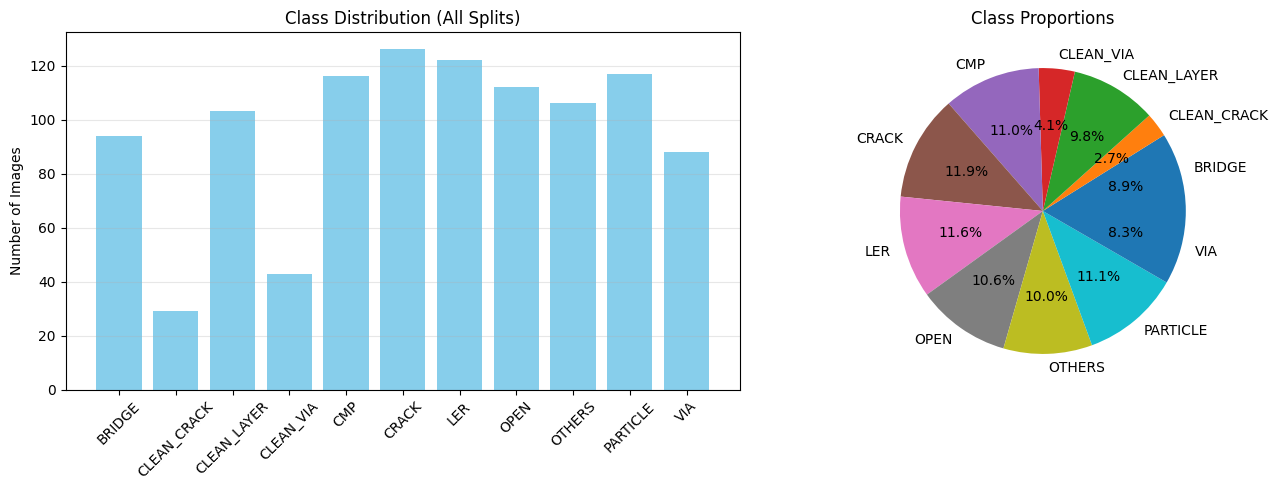

Class Imbalance Ratio (Max/Min): 4.34x


In [41]:
# Aggregate class counts
class_counts = {c: train_class_counts.get(c, 0) + val_class_counts.get(c, 0) + test_class_counts.get(c, 0) for c in categories}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(class_counts.keys(), class_counts.values(), color='skyblue')
axes[0].set_title('Class Distribution (All Splits)')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

imbalance_ratio = max(class_counts.values()) / max(1, min(class_counts.values()))
print(f"Class Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}x")

## 6. Label Encoding & Class Weights

In [42]:
label_encoder = LabelEncoder()
all_labels = train_labels_raw + val_labels_raw + test_labels_raw
label_encoder.fit(all_labels)

train_labels = label_encoder.transform(train_labels_raw)
val_labels = label_encoder.transform(val_labels_raw)
test_labels = label_encoder.transform(test_labels_raw)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class Weights:")
for cls, w in zip(label_encoder.classes_, class_weights):
    print(f"  {cls:15s}: {w:.3f}")

Class Weights:
  BRIDGE         : 1.017
  CLEAN_CRACK    : 3.316
  CLEAN_LAYER    : 0.930
  CLEAN_VIA      : 2.243
  CMP            : 0.829
  CRACK          : 0.763
  LER            : 0.786
  OPEN           : 0.857
  OTHERS         : 0.908
  PARTICLE       : 0.820
  VIA            : 1.090


## 7. Transforms (Safe Augmentation Only)

In [43]:
from torchvision import transforms

# ImageNet normalization (required for pretrained models)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ================= TRAIN TRANSFORM =================
# Offline augmentation already applied → NO online augmentation here
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # Convert SEM grayscale → 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ================= VAL / TEST TRANSFORM =================
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("✓ Final transform block loaded (Offline augmentation only, high accuracy)")


✓ Final transform block loaded (Offline augmentation only, high accuracy)


## 8. Custom Dataset & DataLoaders

In [44]:
class DefectDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = DefectDataset(train_paths, train_labels, transform=train_transform)
val_dataset = DefectDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = DefectDataset(test_paths, test_labels, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("✓ DataLoaders ready")

✓ DataLoaders ready


## 9. Build MobileNetV2 (Transfer Learning)

In [45]:
class MobileNetDefectClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=pretrained)

        # Freeze early layers, unfreeze last 3 blocks for fine-tuning
        for i, feature in enumerate(self.mobilenet.features):
            if i < 15:  # Freeze first 15 layers
                for p in feature.parameters():
                    p.requires_grad = False
            else:  # Unfreeze last layers for fine-tuning
                for p in feature.parameters():
                    p.requires_grad = True

        # Enhanced classifier head with BatchNorm
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

model = MobileNetDefectClassifier(num_classes=num_classes, pretrained=True).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✓ MobileNetV2 model created")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

✓ MobileNetV2 model created
Total params: 2,586,891
Trainable params: 1,889,099


d:\IESA_DeepTech\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IESA_DeepTech\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 10. Loss, Optimizer, Scheduler, AMP

In [46]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    [
        {
            'params': model.mobilenet.features.parameters(),
            'lr': LR_BODY      # 🔥 slow fine-tuning
        },
        {
            'params': model.mobilenet.classifier.parameters(),
            'lr': LR_HEAD      # 🔥 fast learning head
        }
    ],
    weight_decay=0.01
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2
)

scaler = torch.amp.GradScaler('cuda')


print("✓ Loss, optimizer, scheduler, and AMP configured")
print(f"  - Label smoothing: 0.1")
print(f"  - Optimizer: AdamW with weight decay")
print(f"  - Scheduler: CosineAnnealingWarmRestarts")

✓ Loss, optimizer, scheduler, and AMP configured
  - Label smoothing: 0.1
  - Optimizer: AdamW with weight decay
  - Scheduler: CosineAnnealingWarmRestarts


## 11. Train/Validate Functions + Collapse Detection

In [47]:
def train_epoch(model, train_loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': running_loss/len(pbar), 'acc': 100.*correct/total})

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device, return_preds=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if return_preds:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total

    if return_preds:
        return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)
    return epoch_loss, epoch_acc


def check_prediction_collapse(preds, label_encoder, threshold=0.9):
    """Detect if model predicts mostly one class."""
    if len(preds) == 0:
        return False
    unique, counts = np.unique(preds, return_counts=True)
    max_frac = counts.max() / counts.sum()
    if max_frac >= threshold:
        dominant_class = label_encoder.classes_[unique[np.argmax(counts)]]
        print(f"⚠️  Possible prediction collapse: {dominant_class} = {max_frac:.1%} of predictions")
        return True
    return False

## 12. Train Model (Early Stopping)

In [48]:
# ================================
# 🚀 TRAINING LOOP
# ================================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("="*70)
print("🚀 STARTING TRAINING")
print("="*70)

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 70)

    # ----------------------------
    # TRAIN
    # ----------------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device).long()   # 🔥 Ensure correct dtype

        optimizer.zero_grad()

        # AMP safe execution
        with torch.amp.autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # ----------------------------
    # VALIDATION
    # ----------------------------
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device).long()   # 🔥 Ensure correct dtype

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Collapse check
    check_prediction_collapse(val_preds, label_encoder)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_mobilenet_improved.pth')
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%)")

training_time = time.time() - start_time

print("\n" + "="*70)
print("✓ TRAINING COMPLETED")
print(f"Total Time: {training_time:.2f} seconds")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
print("="*70)

🚀 STARTING TRAINING

Epoch 1/60
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:00<00:00, 30.67it/s]


Train Loss: 2.3724 | Train Acc: 19.07%
Val Loss:   1.9936 | Val Acc:   31.00%
✓ Saved best model (Val Acc: 31.00%)

Epoch 2/60
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:00<00:00, 32.38it/s]


Train Loss: 2.0500 | Train Acc: 36.23%
Val Loss:   1.8262 | Val Acc:   34.00%
✓ Saved best model (Val Acc: 34.00%)

Epoch 3/60
----------------------------------------------------------------------


...

Train Loss: 0.9974 | Train Acc: 85.10%
Val Loss:   1.7117 | Val Acc:   48.00%

Epoch 59/60
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:00<00:00, 27.38it/s]


Train Loss: 0.9923 | Train Acc: 85.82%
Val Loss:   1.6627 | Val Acc:   52.00%

Epoch 60/60
----------------------------------------------------------------------


Validation: 100%|██████████| 4/4 [00:00<00:00, 27.23it/s]

Train Loss: 0.9789 | Train Acc: 86.17%
Val Loss:   1.6906 | Val Acc:   51.00%

✓ TRAINING COMPLETED
Total Time: 93.29 seconds
Best Val Accuracy: 54.00%


## 13. Evaluate on Test Set (Accuracy, Precision, Recall, F1)

In [49]:
# Load best model
model.load_state_dict(torch.load('best_model_mobilenet_improved.pth'))
model.eval()

# Test evaluation
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report (as dictionary for metric extraction)
from sklearn.metrics import precision_recall_fscore_support

print("\n" + "="*70)
print("📊 TEST SET METRICS")
print("="*70)
print(classification_report(
    all_labels, all_preds,
    target_names=label_encoder.classes_,
    digits=4
))
print("="*70)

# Extract macro-averaged metrics
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0
)

# Overall accuracy
overall_acc = (all_preds == all_labels).mean() * 100
print(f"Overall Accuracy: {overall_acc:.2f}%")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")


📊 TEST SET METRICS
              precision    recall  f1-score   support

      BRIDGE     0.7143    0.5000    0.5882        10
 CLEAN_CRACK     0.6667    0.5000    0.5714         4
 CLEAN_LAYER     0.4000    0.5455    0.4615        11
   CLEAN_VIA     0.5714    0.8000    0.6667         5
         CMP     0.5000    0.4615    0.4800        13
       CRACK     0.9286    0.9286    0.9286        14
         LER     0.5714    0.6154    0.5926        13
        OPEN     0.5333    0.6667    0.5926        12
      OTHERS     0.8571    0.5000    0.6316        12
    PARTICLE     0.6364    0.5385    0.5833        13
         VIA     0.7500    0.9000    0.8182        10

    accuracy                         0.6325       117
   macro avg     0.6481    0.6324    0.6286       117
weighted avg     0.6535    0.6325    0.6323       117

Overall Accuracy: 63.25%
Precision (macro): 0.6481
Recall (macro): 0.6324
F1-Score (macro): 0.6286


## 14. Confusion Matrix

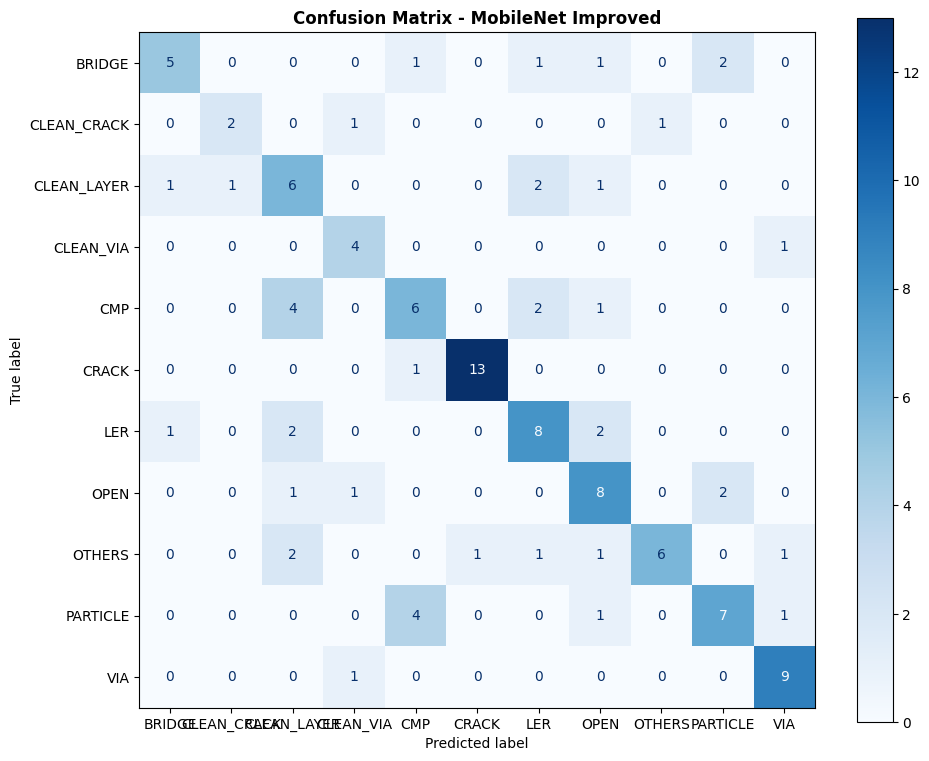

In [50]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - MobileNet Improved', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Overfitting / Underfitting Diagnostics

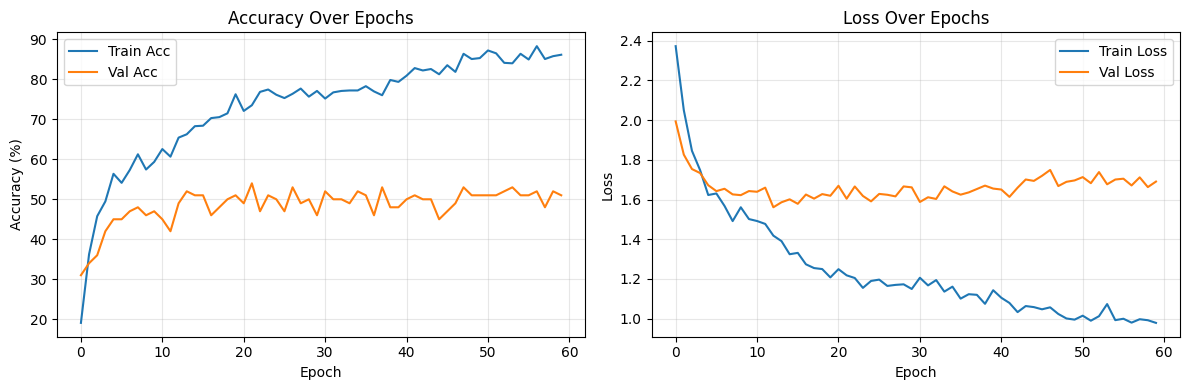


Interpretation: 
- Overfitting: train acc high, val acc low, val loss rising
- Underfitting: both accuracies low, loss not decreasing


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_acc'], label='Train Acc')
axes[0].plot(history['val_acc'], label='Val Acc')
axes[0].set_title('Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'], label='Val Loss')
axes[1].set_title('Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation: ")
print("- Overfitting: train acc high, val acc low, val loss rising")
print("- Underfitting: both accuracies low, loss not decreasing")

## 16. Save Weights and Export ONNX

In [52]:
import sys
import subprocess

# This forces installation into the CORRECT environment that Jupyter is using
print(f"Installing into: {sys.executable}")
subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx", "onnxruntime"])
print("\n✅ Installation complete. NOW RESTART THE KERNEL.")
# ================= MASTER FIX: REBUILD & EXPORT =================
import torch
import torch.nn as nn
from torchvision import models
import pickle
import os
from sklearn.preprocessing import LabelEncoder

# 1. SETUP CONFIGURATION (Must match training!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 128
categories = [
    'BRIDGE',
    'CLEAN_CRACK',
    'CLEAN_LAYER',
    'CLEAN_VIA',
    'CMP',
    'CRACK',
    'LER',
    'OPEN',
    'OTHERS',
    'PARTICLE',
    'VIA'
]

# 2. REBUILD LABEL ENCODER
label_encoder = LabelEncoder()
label_encoder.fit(categories)

# 3. REDEFINE THE MODEL ARCHITECTURE
# (Python needs to know the shape of the model to load weights into it)
class MobileNetDefectClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=False):
        super().__init__()
        # We don't need pretrained weights here because we are loading our own
        self.mobilenet = models.mobilenet_v2(pretrained=False)

        # Re-create the exact same head used in training
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

# 4. INITIALIZE MODEL & LOAD WEIGHTS
print("🔄 Rebuilding model architecture...")
model = MobileNetDefectClassifier(num_classes=len(categories)).to(device)

weights_path = "best_model_mobilenet_improved.pth"
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("✓ Loaded best weights from file")
else:
    print(f"❌ ERROR: '{weights_path}' not found! You must train the model first.")

# 5. SAVE ARTIFACTS
# Save label encoder
with open("label_encoder_mobilenet_improved.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# ---------------- ONNX EXPORT ----------------
print("🔄 Starting ONNX export...")
model.eval()

# Create dummy input
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
onnx_path = "defect_classification_mobilenet_improved.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    dynamo=False   # ✅ Forces legacy exporter (Fixes 'onnxscript' error)
)

print("\n✅ ONNX export successful")
print("Saved files:")
print(f" - {weights_path}")
print(" - label_encoder_mobilenet_improved.pkl")
print(f" - {onnx_path}")

Installing into: d:\IESA_DeepTech\venv\python.exe

✅ Installation complete. NOW RESTART THE KERNEL.
🔄 Rebuilding model architecture...
✓ Loaded best weights from file
🔄 Starting ONNX export...


d:\IESA_DeepTech\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IESA_DeepTech\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\Harshvardhan Mali\AppData\Local\Temp\ipykernel_17480\3223505323.py:87: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



✅ ONNX export successful
Saved files:
 - best_model_mobilenet_improved.pth
 - label_encoder_mobilenet_improved.pkl
 - defect_classification_mobilenet_improved.onnx


In [53]:
import os
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType

# --- 1. CONFIGURATION ---
fp32_model_path = "defect_classification_mobilenet_improved.onnx"
int8_model_path = "defect_classification_mobilenet_improved_int8.onnx"

# --- 2. DIRECT INT8 QUANTIZATION ---
print("🔄 Starting Direct INT8 Quantization...")
quantize_dynamic(
    model_input=fp32_model_path,
    model_output=int8_model_path,
    weight_type=QuantType.QUInt8  # Forces 8-bit Integer weights
)
print(f"✅ Quantization Successful! INT8 model saved as: {int8_model_path}")

# --- 3. VERIFY FILE SIZE REDUCTION ---
if os.path.exists(int8_model_path):
    fp32_size = os.path.getsize(fp32_model_path) / (1024 * 1024)
    int8_size = os.path.getsize(int8_model_path) / (1024 * 1024)
    print("\n📊 STORAGE COMPARISON:")
    print(f" - Original FP32 Size : {fp32_size:.2f} MB")
    print(f" - Quantized INT8 Size: {int8_size:.2f} MB")
    print(f" - Reduction Factor   : {fp32_size / int8_size:.2f}x smaller")

🔄 Starting Direct INT8 Quantization...
✅ Quantization Successful! INT8 model saved as: defect_classification_mobilenet_improved_int8.onnx

📊 STORAGE COMPARISON:
 - Original FP32 Size : 9.85 MB
 - Quantized INT8 Size: 2.67 MB
 - Reduction Factor   : 3.69x smaller


In [8]:
# ================================================================
# 📂 PHASE 3 – FINAL PREDICTION + LOG + SUBMISSION CSV
# EdgeIntel | Idea ID 268
# ================================================================

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import datetime
import platform
import pickle
import pandas as pd
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms

# ------------------------------------------------
# 🔹 CONFIGURATION
# ------------------------------------------------
IDEA_ID = "268"
TEAM_NAME = "EdgeIntel"
TEAM_LEADER = "Harshvardhan Bharat Mali"

MODEL_FILE = r"D:\Final_3_End\model\best_model_mobilenet_improved.pth"
LABEL_ENCODER_FILE = r"D:\Final_3_End\model\label_encoder_mobilenet_improved.pkl"
PREDICTION_DATASET = r"D:\Final_3_End\Hackathon_phase3_prediction_dataset"

INPUT_SIZE = 128
TEMPERATURE = 1.0

LOG_FILE = "PHASE3_PREDICTION_LOG.txt"
SUBMISSION_FILE = "EdgeIntel_268_Phase3_Submission.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------
# 🔹 LOAD LABEL ENCODER
# ------------------------------------------------
with open(LABEL_ENCODER_FILE, "rb") as f:
    label_encoder = pickle.load(f)

class_names = label_encoder.classes_
NUM_CLASSES = len(class_names)

print("✅ Label encoder loaded")
print("Classes:", class_names)

# ------------------------------------------------
# 🔹 LOAD CHECKPOINT AND FIX KEYS
# ------------------------------------------------
checkpoint = torch.load(MODEL_FILE, map_location=device)

# Remove 'mobilenet.' prefix from checkpoint keys to match models.mobilenet_v2 structure
cleaned_checkpoint = {}
for key, value in checkpoint.items():
    if key.startswith('mobilenet.'):
        new_key = key.replace('mobilenet.', '', 1)
        cleaned_checkpoint[new_key] = value
    else:
        cleaned_checkpoint[key] = value

# ------------------------------------------------
# 🔹 BUILD MODEL DYNAMICALLY (MATCH CHECKPOINT)
# ------------------------------------------------
model = models.mobilenet_v2(weights=None)

# Replace classifier with SAME structure as checkpoint
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, NUM_CLASSES)
)

# Load weights strictly using the cleaned checkpoint
model.load_state_dict(cleaned_checkpoint, strict=True)

model.to(device)
model.eval()

print("✅ Model loaded successfully without mismatch")

# ------------------------------------------------
# 🔹 IMAGE PREPROCESSING (MATCH TRAINING)
# ------------------------------------------------
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ------------------------------------------------
# 🔹 LOAD IMAGES
# ------------------------------------------------
image_paths = []

for file in os.listdir(PREDICTION_DATASET):
    if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        image_paths.append(os.path.join(PREDICTION_DATASET, file))

image_paths.sort()

print(f"📂 Total Images Found: {len(image_paths)}")

# ------------------------------------------------
# 🔹 RUN INFERENCE
# ------------------------------------------------
predicted_labels = []
confidence_scores = []

print("🚀 Running Inference...")

with torch.no_grad():
    for img_path in tqdm(image_paths):

        image = Image.open(img_path)
        image = val_transform(image)
        image = image.unsqueeze(0).to(device)

        outputs = model(image)
        outputs = outputs / TEMPERATURE

        probs = F.softmax(outputs, dim=1)
        confidence, pred_class = torch.max(probs, dim=1)

        predicted_labels.append(class_names[pred_class.item()])
        confidence_scores.append(float(confidence.item()))

print("✅ Inference Completed")

# ------------------------------------------------
# 🔹 GENERATE SUBMISSION CSV
# ------------------------------------------------
submission_df = pd.DataFrame({
    "Image_Name": [os.path.basename(p) for p in image_paths],
    "Predicted_Label": predicted_labels
})

submission_df.to_csv(SUBMISSION_FILE, index=False)

print(f"✅ Submission file generated: {SUBMISSION_FILE}")

# ------------------------------------------------
# 🔹 GENERATE LOG FILE
# ------------------------------------------------
with open(LOG_FILE, "w", encoding="utf-8") as f:

    def log(text):
        print(text)
        f.write(text + "\n")

    log("="*80)
    log("DEEPTECH HACKATHON 2026 - PHASE 3 PREDICTION LOG")
    log("="*80)

    log(f"Date & Time    : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log(f"Idea ID        : {IDEA_ID}")
    log(f"Team Name      : {TEAM_NAME}")
    log(f"Team Leader    : {TEAM_LEADER}")
    log("-"*80)

    log("\n[ENVIRONMENT]")
    log(f"Python Version : {sys.version.split()[0]}")
    log(f"PyTorch Version: {torch.__version__}")
    log(f"NumPy Version  : {np.__version__}")

    log("\n[CONFIGURATION]")
    log(f"Model File     : {MODEL_FILE}")
    log(f"Dataset Folder : {PREDICTION_DATASET}")
    log(f"Input Size     : {INPUT_SIZE}x{INPUT_SIZE}")
    log(f"Temperature    : {TEMPERATURE}")
    log(f"Total Samples  : {len(predicted_labels)}")
    log(f"Classes        : {list(class_names)}")

    log("\n" + "="*80)
    log("[PREDICTIONS]")
    log("="*80)
    log(f"{'Image Name':<40} | {'Predicted Label':<15} | Confidence")
    log("-"*85)

    for img_name, pred, conf in zip(
        [os.path.basename(p) for p in image_paths],
        predicted_labels,
        confidence_scores
    ):
        log(f"{img_name:<40} | {pred:<15} | {conf:.4f}")

    log("="*80)
    log("END OF LOG")

print(f"✅ Log file generated: {LOG_FILE}")
print("\n🎯 PHASE-3 SUBMISSION READY")

✅ Label encoder loaded
Classes: ['BRIDGE' 'CLEAN_CRACK' 'CLEAN_LAYER' 'CLEAN_VIA' 'CMP' 'CRACK' 'LER'
 'OPEN' 'OTHERS' 'PARTICLE' 'VIA']
✅ Model loaded successfully without mismatch
📂 Total Images Found: 331
🚀 Running Inference...


100%|██████████| 331/331 [00:05<00:00, 56.50it/s]

✅ Inference Completed
✅ Submission file generated: EdgeIntel_268_Phase3_Submission.csv
DEEPTECH HACKATHON 2026 - PHASE 3 PREDICTION LOG
Date & Time    : 2026-02-25 21:35:36
Idea ID        : 268
Team Name      : EdgeIntel
Team Leader    : Harshvardhan Bharat Mali
--------------------------------------------------------------------------------

[ENVIRONMENT]
Python Version : 3.12.0
PyTorch Version: 2.10.0+cu130
NumPy Version  : 1.26.4

[CONFIGURATION]
Model File     : D:\Final_3_End\model\best_model_mobilenet_improved.pth
Dataset Folder : D:\Final_3_End\Hackathon_phase3_prediction_dataset
Input Size     : 128x128
Temperature    : 1.0
Total Samples  : 331
Classes        : ['BRIDGE', 'CLEAN_CRACK', 'CLEAN_LAYER', 'CLEAN_VIA', 'CMP', 'CRACK', 'LER', 'OPEN', 'OTHERS', 'PARTICLE', 'VIA']

[PREDICTIONS]
Image Name                               | Predicted Label | Confidence
-------------------------------------------------------------------------------------
100.png                            